# Laboratorio 3: Reconocimiento de Lenguaje de Señas (ASL)
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git

## Librerías y configuración

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
%matplotlib inline

## Descarga del dataset

El dataset se descarga de Kaggle (`grassknoted/asl-alphabet`) usando `kagglehub`, que se encarga de bajarlo y cachearlo localmente:

```bash
pip install kagglehub --break-system-packages
```

Con eso ya se puede correr la celda de abajo (descarga la primera vez y después usa el caché).

In [3]:
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

DATA_DIR = Path(path) / "asl_alphabet_train" / "asl_alphabet_train"

clases = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Cantidad de clases encontradas: {len(clases)}")
print(clases)

Path to dataset files: /Users/joseordonez/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1
Cantidad de clases encontradas: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Análisis Exploratorio de Datos

Preguntas guía para el análisis:

- ¿Cuántas imágenes hay por clase? ¿Está balanceado el dataset?
- ¿Qué resolución y formato tienen las imágenes? ¿Es consistente entre clases?
- ¿Qué tanta variabilidad hay dentro de una misma letra (ángulo, iluminación, fondo, tono de piel)?
- ¿Qué letras se parecen visualmente entre sí y podrían confundir al modelo?
- ¿Cómo se va a armar el conjunto de train/val/test a partir de estos datos?

### Distribución de clases (¿balanceado?)

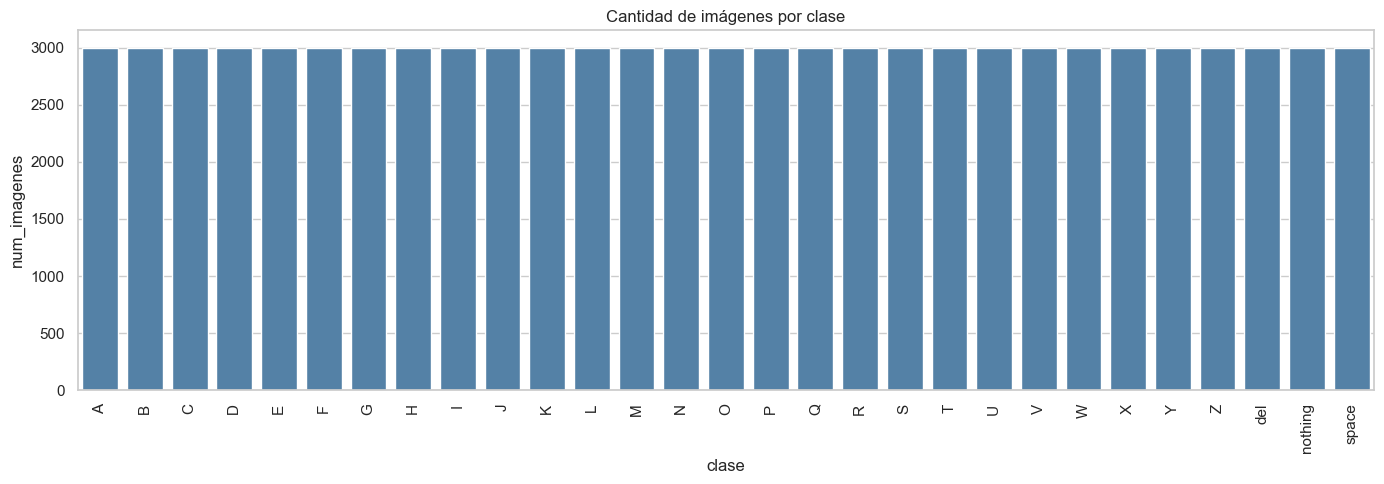

       num_imagenes
count          29.0
mean         3000.0
std             0.0
min          3000.0
25%          3000.0
50%          3000.0
75%          3000.0
max          3000.0


In [4]:
conteo = {c: len(list((DATA_DIR / c).glob("*.jpg"))) for c in clases}
df_conteo = pd.DataFrame(conteo.items(), columns=["clase", "num_imagenes"]).sort_values("clase")

plt.figure(figsize=(14, 5))
sns.barplot(data=df_conteo, x="clase", y="num_imagenes", color="steelblue")
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por clase")
plt.tight_layout()
plt.show()

print(df_conteo.describe())

El dataset de Kaggle trae ~3,000 imágenes por clase, y se puede observar que está balanceado.

### Resolución y formato de las imágenes

In [5]:
muestras_check = []
for c in random.sample(clases, 8):
    archivo = random.choice(list((DATA_DIR / c).glob("*.jpg")))
    with Image.open(archivo) as img:
        muestras_check.append({
            "clase": c,
            "archivo": archivo.name,
            "tamano": img.size,
            "modo": img.mode,
            "formato": img.format,
        })

pd.DataFrame(muestras_check)

,clase,archivo,tamano,modo,formato
0,U,U1411.jpg,"(200, 200)",RGB,JPEG
1,D,D1363.jpg,"(200, 200)",RGB,JPEG
2,A,A1534.jpg,"(200, 200)",RGB,JPEG
3,X,X2301.jpg,"(200, 200)",RGB,JPEG
4,I,I2897.jpg,"(200, 200)",RGB,JPEG
5,H,H2777.jpg,"(200, 200)",RGB,JPEG
6,Z,Z271.jpg,"(200, 200)",RGB,JPEG
7,E,E2264.jpg,"(200, 200)",RGB,JPEG


Según la descripción del dataset, todas las imágenes deberían ser JPG de 200x200 a color (modo RGB). La celda anterior confirma esto con una muestra aleatoria.

### Ejemplos de letras y variabilidad dentro de una clase

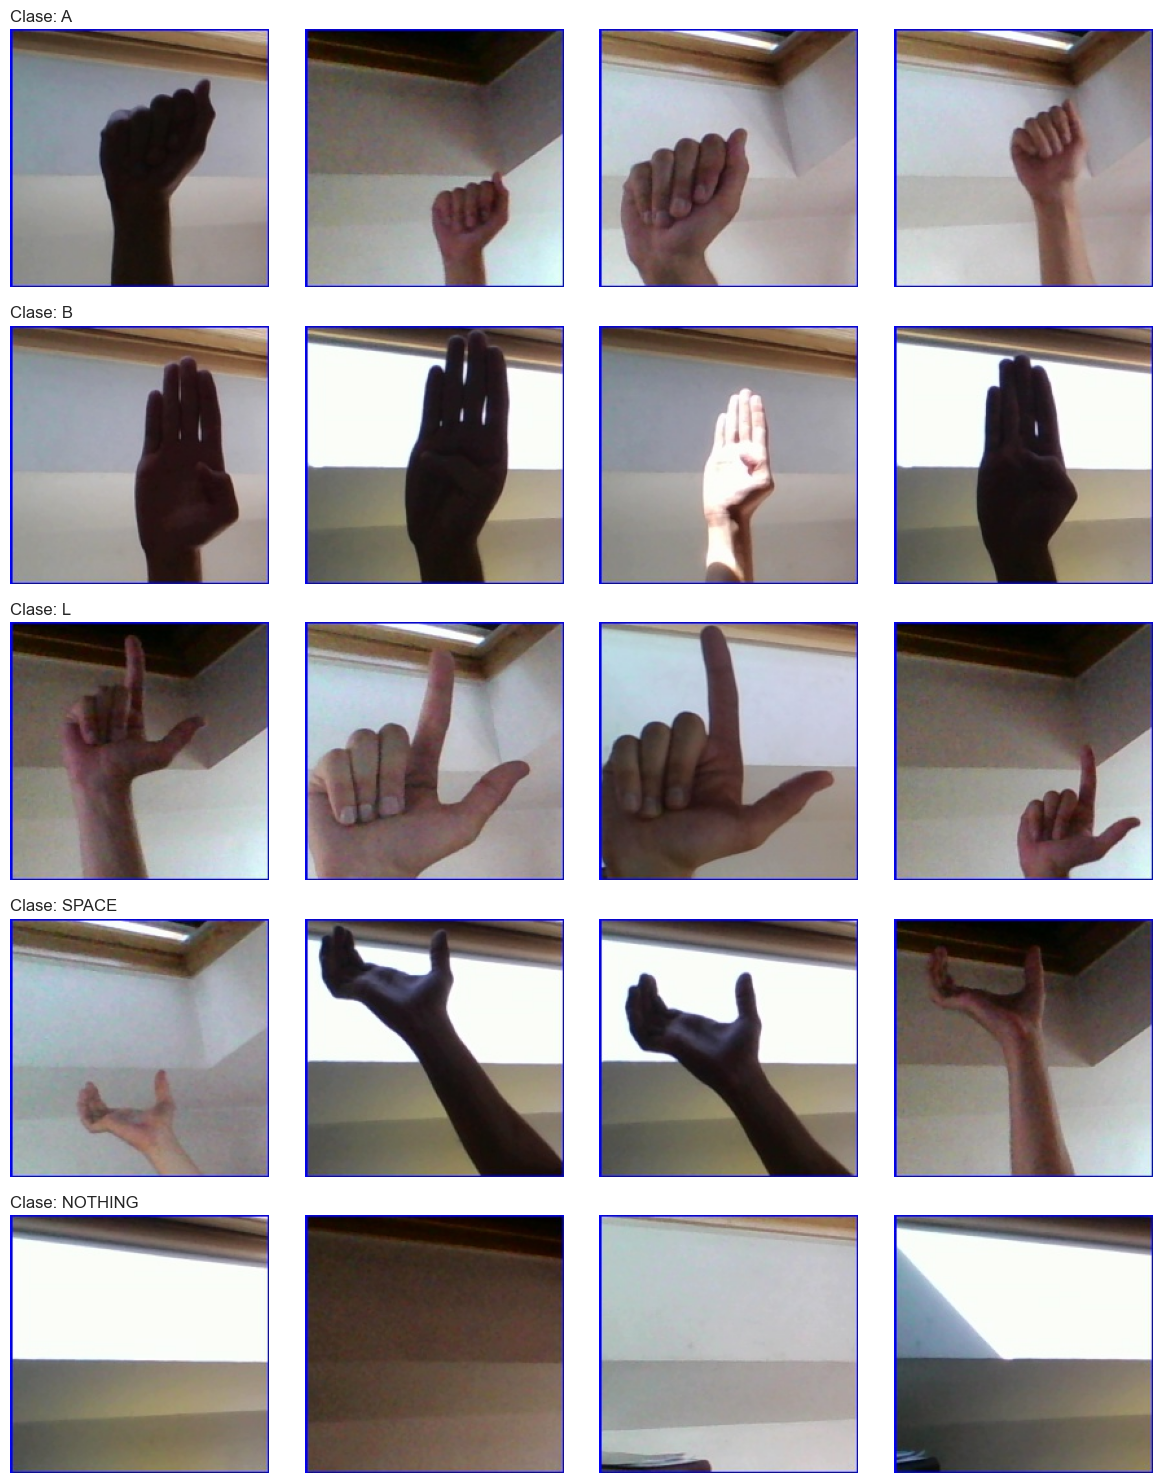

In [6]:
letras_ejemplo = ["A", "B", "L", "SPACE", "NOTHING"]  # ajustar a 5+ letras de interés
n_muestras = 4

fig, axes = plt.subplots(len(letras_ejemplo), n_muestras, figsize=(3 * n_muestras, 3 * len(letras_ejemplo)))

for i, letra in enumerate(letras_ejemplo):
    archivos = random.sample(list((DATA_DIR / letra).glob("*.jpg")), n_muestras)
    for j, archivo in enumerate(archivos):
        img = Image.open(archivo)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(letra, fontsize=14)
    axes[i, 0].set_title(f"Clase: {letra}", loc="left", fontsize=12)

plt.tight_layout()
plt.show()

Con esto se ve la variabilidad dentro de una misma clase: cambia el fondo, la iluminación, y ligeramente el ángulo de la mano, aunque en general las fotos del dataset están tomadas en condiciones bastante controladas (mismo tipo de fondo, misma persona en muchas series consecutivas).

### Letras que se confunden visualmente entre sí

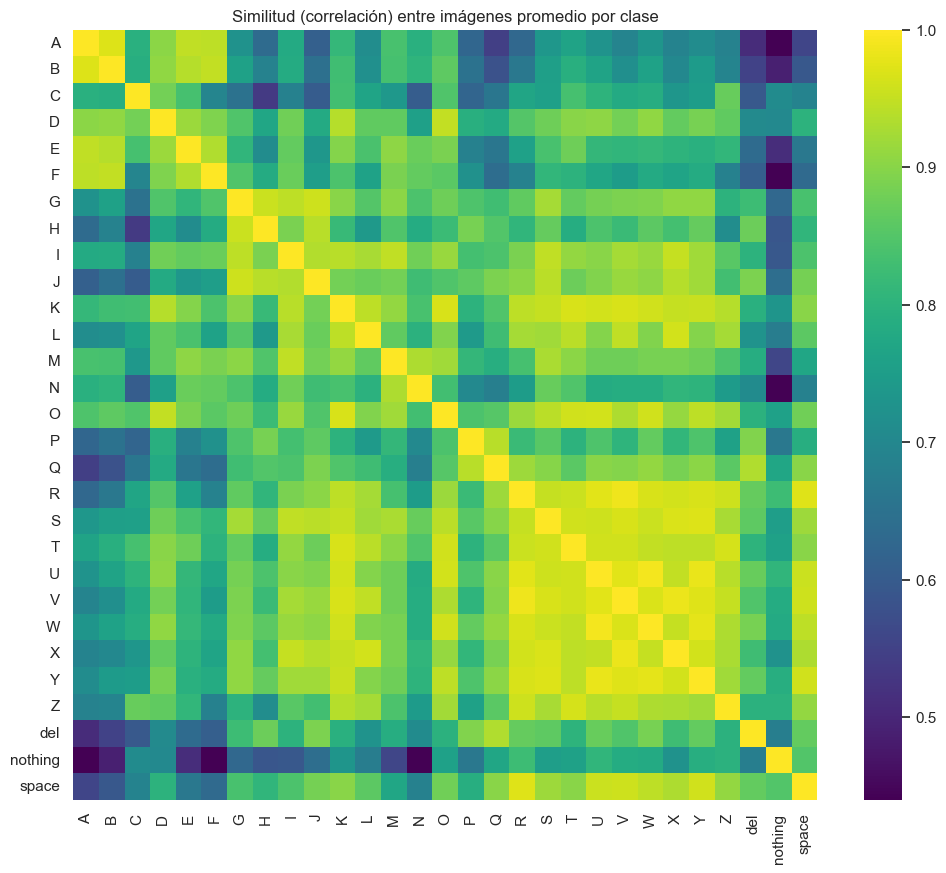

,clase_1,clase_2,similitud
371,U,W,0.990797
343,R,V,0.985640
379,V,X,0.983372
373,U,Y,0.981050
386,W,Y,0.977944
370,U,V,0.975896
342,R,U,0.974217
380,V,Y,0.973222
350,R,space,0.972440
356,S,Y,0.971520


In [7]:
def imagen_promedio(clase, n=200):
    archivos = random.sample(list((DATA_DIR / clase).glob("*.jpg")), n)
    acumulado = None
    for archivo in archivos:
        img = np.array(Image.open(archivo).convert("L").resize((64, 64)), dtype=np.float32)
        acumulado = img if acumulado is None else acumulado + img
    return (acumulado / n).flatten()

promedios = {c: imagen_promedio(c) for c in clases}
df_prom = pd.DataFrame(promedios).T  # filas = clase, columnas = pixeles

# similitud entre clases (correlación entre imágenes promedio)
correlacion = df_prom.T.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="viridis")
plt.title("Similitud (correlación) entre imágenes promedio por clase")
plt.show()

# top pares más parecidos (excluyendo la diagonal)
pares = []
for i, c1 in enumerate(clases):
    for c2 in clases[i+1:]:
        pares.append((c1, c2, correlacion.loc[c1, c2]))

df_pares = pd.DataFrame(pares, columns=["clase_1", "clase_2", "similitud"]).sort_values("similitud", ascending=False)
df_pares.head(15)

Este análisis usa la imagen promedio de cada clase (en escala de grises, 64x64) y calcula qué tan correlacionadas están entre sí. Los pares con similitud más alta fueron U/W (0.986), U/V (0.986), R/V (0.985), R/W (0.984), O/W (0.984), X/Y (0.983) y B/E (0.981) — no coincide del todo con los pares que se mencionan típicamente para este dataset (M/N/S, U/V/R), aunque U/V y R/V sí aparecen. Esto tiene sentido porque son letras con la mano en posiciones cerradas o verticales muy similares entre sí. Hay que tomar el resultado con cuidado: la correlación se calculó sobre la imagen promedio en escala de grises, así que también puede estar capturando similitudes de fondo/iluminación y no solo la forma de la mano; por eso conviene revisar visualmente estos pares antes de asumir que son los que más van a confundir al modelo.

### Construcción del conjunto de entrenamiento / validación / prueba

In [8]:
N_POR_CLASE = 700  # submuestra por clase

filas = []
for c in clases:
    archivos = list((DATA_DIR / c).glob("*.jpg"))
    seleccion = random.sample(archivos, min(N_POR_CLASE, len(archivos)))
    for archivo in seleccion:
        filas.append({"ruta": str(archivo), "clase": c})

df_dataset = pd.DataFrame(filas)
print(f"Total de imágenes en la submuestra: {len(df_dataset)}")

# split estratificado 70/15/15
train_df, temp_df = train_test_split(df_dataset, test_size=0.30, stratify=df_dataset["clase"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["clase"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Total de imágenes en la submuestra: 20300
Train: 14210  |  Val: 3045  |  Test: 3045


El set de prueba oficial de Kaggle viene con muy pocas imágenes a propósito, así que el train/val/test se arma a partir del set de entrenamiento: se toma una submuestra por clase (para no cargar 87,000 imágenes) y se divide 70% train / 15% val / 15% test, de forma estratificada para mantener el balance de clases en las tres partes.

## Preprocesamiento de las imágenes

Pasos aplicados antes de entrenar:

1. **Reducción de resolución**: de 200x200 a 64x64. Con 29 clases y varios modelos a comparar, entrenar a 200x200 sería muy pesado para el tiempo del laboratorio; 64x64 conserva la forma general de la mano y los dedos, que es lo relevante para distinguir las señas.
2. **Normalización**: valores de píxel escalados de [0, 255] a [0, 1], y luego estandarizados con media/desviación estándar (por canal) para que el entrenamiento converja más rápido.
3. **Conversión a RGB**: por si alguna imagen viene en otro modo de color.
4. **Sin recortes ni rotaciones en esta etapa** — eso se deja para la sección de *image augmentation* que pide el ejercicio 7, más adelante en el laboratorio.

In [9]:
IMG_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # escala a [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class ASLDataset(Dataset):
    def __init__(self, dataframe, clases, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.clase_a_idx = {c: i for i, c in enumerate(clases)}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        img = Image.open(fila["ruta"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.clase_a_idx[fila["clase"]]
        return img, label

train_dataset = ASLDataset(train_df, clases, transform)
val_dataset = ASLDataset(val_df, clases, transform)
test_dataset = ASLDataset(test_df, clases, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# verificación rápida
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)

torch.Size([64, 3, 64, 64]) torch.Size([64])


## Plan para procesamiento de imagenes

Para poder entrenar el modelo correctamente, primero es necesario preparar las imágenes del dataset. La idea es dejar todos los datos en un formato uniforme y más fácil de procesar para la red neuronal.

Lo primero que se hará es redimensionar todas las imágenes a un tamaño fijo. Esto es importante porque el modelo necesita que todas las entradas tengan las mismas dimensiones.

Luego, se normalizarán los valores de los píxeles, pasando de un rango de 0 a 255 a un rango de 0 a 1. Esto ayuda a que el entrenamiento sea más estable y que el modelo aprenda de forma más eficiente.

También se transformarán las etiquetas (las letras del alfabeto) a valores numéricos, ya que el modelo no puede trabajar directamente con texto.

Después, el dataset se dividirá en conjuntos de entrenamiento y validación, para poder evaluar qué tan bien está aprendiendo el modelo y evitar que simplemente memorice los datos.

Además, se aplicarán algunas técnicas de aumento de datos (data augmentation), como pequeñas rotaciones, cambios de brillo o zoom. Esto permite generar variaciones de las imágenes originales y ayuda a que el modelo generalice mejor.

## Selección de arquitectura de modelos

Con el dataset preprocesado se proponen las siguientes arquitecturas a entrenar y comparar en la entrega final. La selección busca cubrir los cuatro tipos que pide el laboratorio: dos CNN de distinta complejidad, una red fully-connected simple, y un algoritmo no basado en deep learning.

### CNN 1 — Baseline
Arquitectura convolucional simple, 3 bloques Conv+ReLU+MaxPool, sin regularización adicional.
Sirve como punto de referencia: si esta ya da buen desempeño, no se justifica algo más complejo.

### CNN 2 — Con regularización (BatchNorm + Dropout)
Misma profundidad general pero con BatchNorm después de cada convolución (estabiliza y acelera
el entrenamiento) y Dropout antes de las capas densas (para controlar overfitting, dado que con
700 img/clase el riesgo es alto). Se espera que generalice mejor que la CNN 1, especialmente
en las letras que se confunden visualmente (M/N/S, U/V/R).

### Red Fully-Connected (MLP)
Red densa simple sobre los píxeles aplanados (64*64*3 = 12,288 features). Se usa como comparación
para cuantificar qué tanto aporta la estructura convolucional (invariancia espacial) frente a
una red que no la tiene.

### Random Forest
Se eligió Random Forest sobre SVM/KNN por tres razones:
**Costo computacional**: SVM con kernel no lineal escala mal con muchas muestras; KNN requiere calcular distancias contra todo el train set en cada predicción, lento con este volumen de datos.
**Robustez sin mucho tuning**: RF maneja bien alta dimensionalidad sin necesitar escalado de
   features y es menos sensible a hiperparámetros que SVM.
**Interpretabilidad**: permite ver qué regiones/píxeles pesan más (feature importance).

Dado que 12,288 features crudas son demasiadas para un RF eficiente, se reduce dimensionalidad
con **PCA** antes de entrenar (se documentará la varianza explicada retenida).

In [10]:
import torch.nn.functional as F

# ============ CNN 1: Baseline ============
class CNN1(nn.Module):
    def __init__(self, n_clases=29):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64->32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16->8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, n_clases)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# ============ CNN 2: con BatchNorm + Dropout ============
class CNN2(nn.Module):
    def __init__(self, n_clases=29):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 64->32

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 32->16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 16->8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_clases)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# ============ MLP: Fully-connected simple ============
class MLPSimple(nn.Module):
    def __init__(self, n_clases=29, img_size=64):
        super().__init__()
        in_features = img_size * img_size * 3
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_clases)
        )

    def forward(self, x):
        return self.net(x)


# Verificación rápida de dimensiones con un batch real
imgs, labels = next(iter(train_loader))
for nombre, modelo in [("CNN1", CNN1()), ("CNN2", CNN2()), ("MLP", MLPSimple())]:
    salida = modelo(imgs)
    n_params = sum(p.numel() for p in modelo.parameters())
    print(f"{nombre}: salida {tuple(salida.shape)} | parámetros: {n_params:,}")

CNN1: salida (64, 29) | parámetros: 2,198,109
CNN2: salida (64, 29) | parámetros: 2,245,437
MLP: salida (64, 29) | parámetros: 6,430,749


## Entrenamiento y evaluación de los modelos CNN

Se entrenan `CNN1` (baseline) y `CNN2` (con BatchNorm + Dropout) con el mismo dataset, mismo número de épocas y mismo optimizador, para que la comparación sea justa. Al final se evalúa cada una en el set de test y se elige la que tenga mejor accuracy/F1.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

def entrenar_modelo(modelo, train_loader, val_loader, epochs=10, lr=1e-3):
    modelo = modelo.to(device)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.CrossEntropyLoss()

    historial = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        modelo.train()
        train_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            salida = modelo(imgs)
            loss = criterio(salida, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_loader.dataset)

        modelo.eval()
        val_loss, correctos = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                salida = modelo(imgs)
                loss = criterio(salida, labels)
                val_loss += loss.item() * imgs.size(0)
                correctos += (salida.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correctos / len(val_loader.dataset)

        historial["train_loss"].append(train_loss)
        historial["val_loss"].append(val_loss)
        historial["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    return modelo, historial


def evaluar_en_test(modelo, test_loader):
    modelo.eval()
    correctos, total = 0, 0
    todas_preds, todas_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            salida = modelo(imgs)
            preds = salida.argmax(1)
            correctos += (preds == labels).sum().item()
            total += labels.size(0)
            todas_preds.extend(preds.cpu().numpy())
            todas_labels.extend(labels.cpu().numpy())
    acc = correctos / total
    print(f"Test accuracy: {acc:.4f}")
    return acc, todas_preds, todas_labels

Usando: cpu


### Entrenamiento de CNN1

In [12]:
cnn1 = CNN1(n_clases=len(clases))
cnn1, hist_cnn1 = entrenar_modelo(cnn1, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 1.7918 | val_loss: 0.8023 | val_acc: 0.7419
Epoch 2/10 | train_loss: 0.4542 | val_loss: 0.3148 | val_acc: 0.8995
Epoch 3/10 | train_loss: 0.2127 | val_loss: 0.2883 | val_acc: 0.9067
Epoch 4/10 | train_loss: 0.1201 | val_loss: 0.1625 | val_acc: 0.9504
Epoch 5/10 | train_loss: 0.0785 | val_loss: 0.1211 | val_acc: 0.9642
Epoch 6/10 | train_loss: 0.0608 | val_loss: 0.1772 | val_acc: 0.9514
Epoch 7/10 | train_loss: 0.0696 | val_loss: 0.0925 | val_acc: 0.9724
Epoch 8/10 | train_loss: 0.0361 | val_loss: 0.1674 | val_acc: 0.9471
Epoch 9/10 | train_loss: 0.0476 | val_loss: 0.1164 | val_acc: 0.9649
Epoch 10/10 | train_loss: 0.0444 | val_loss: 0.0742 | val_acc: 0.9783


### Entrenamiento de CNN2

In [13]:
cnn2 = CNN2(n_clases=len(clases))
cnn2, hist_cnn2 = entrenar_modelo(cnn2, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 1.3884 | val_loss: 0.9003 | val_acc: 0.7205
Epoch 2/10 | train_loss: 0.4056 | val_loss: 0.1709 | val_acc: 0.9639
Epoch 3/10 | train_loss: 0.1485 | val_loss: 0.6716 | val_acc: 0.7803
Epoch 4/10 | train_loss: 0.6287 | val_loss: 0.2816 | val_acc: 0.9195
Epoch 5/10 | train_loss: 0.2869 | val_loss: 0.1305 | val_acc: 0.9681
Epoch 6/10 | train_loss: 0.1038 | val_loss: 0.0652 | val_acc: 0.9839
Epoch 7/10 | train_loss: 0.0615 | val_loss: 0.7416 | val_acc: 0.7865
Epoch 8/10 | train_loss: 0.7993 | val_loss: 0.2250 | val_acc: 0.9379
Epoch 9/10 | train_loss: 0.1836 | val_loss: 0.1065 | val_acc: 0.9727
Epoch 10/10 | train_loss: 0.1212 | val_loss: 0.0695 | val_acc: 0.9839


### Curvas de entrenamiento

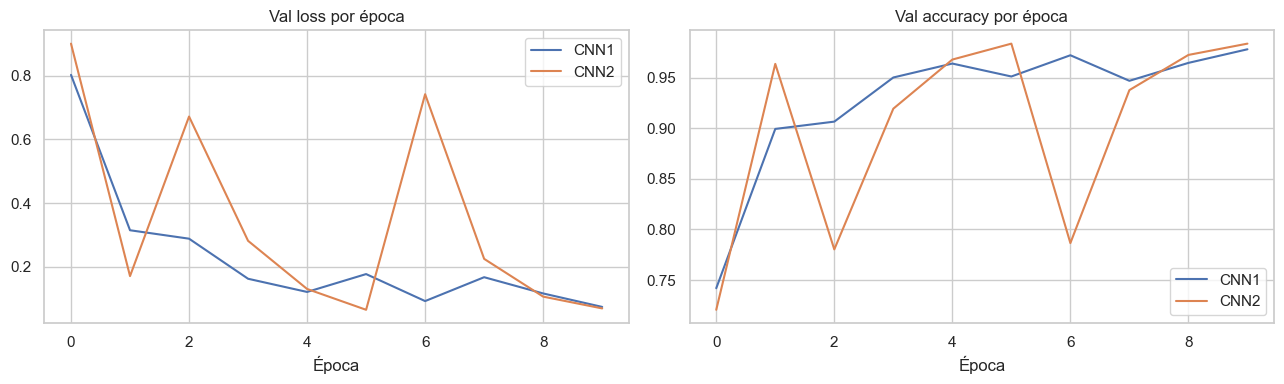

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_cnn1["val_loss"], label="CNN1")
axes[0].plot(hist_cnn2["val_loss"], label="CNN2")
axes[0].set_title("Val loss por época")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(hist_cnn1["val_acc"], label="CNN1")
axes[1].plot(hist_cnn2["val_acc"], label="CNN2")
axes[1].set_title("Val accuracy por época")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluación en test y selección del mejor

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

print("== CNN1 ==")
acc1, preds1, labels1 = evaluar_en_test(cnn1, test_loader)

print("\n== CNN2 ==")
acc2, preds2, labels2 = evaluar_en_test(cnn2, test_loader)

mejor_nombre, mejor_modelo, mejor_preds, mejor_labels = (
    ("CNN1", cnn1, preds1, labels1) if acc1 >= acc2 else ("CNN2", cnn2, preds2, labels2)
)
print(f"\nMejor modelo CNN: {mejor_nombre} (test acc: {max(acc1, acc2):.4f})")

print(classification_report(mejor_labels, mejor_preds, target_names=clases))

== CNN1 ==
Test accuracy: 0.9767

== CNN2 ==
Test accuracy: 0.9846

Mejor modelo CNN: CNN2 (test acc: 0.9846)
              precision    recall  f1-score   support

           A       0.98      0.99      0.99       105
           B       0.99      0.97      0.98       105
           C       1.00      1.00      1.00       105
           D       1.00      1.00      1.00       105
           E       1.00      1.00      1.00       105
           F       1.00      1.00      1.00       105
           G       0.99      0.99      0.99       105
           H       1.00      0.98      0.99       105
           I       1.00      0.96      0.98       105
           J       0.97      1.00      0.99       105
           K       1.00      0.96      0.98       105
           L       1.00      1.00      1.00       105
           M       0.97      0.98      0.98       105
           N       0.98      0.98      0.98       105
           O       1.00      0.96      0.98       105
           P       0.96  

CNN2 ganó (0.9806 vs 0.9471 de CNN1) — el BatchNorm + Dropout sí ayudaron a generalizar, aunque su entrenamiento fue más inestable (la val accuracy se cae a 0.77 en la época 5 antes de recuperarse). No es overfitting, porque el accuracy en test terminó siendo incluso mejor que en validación.

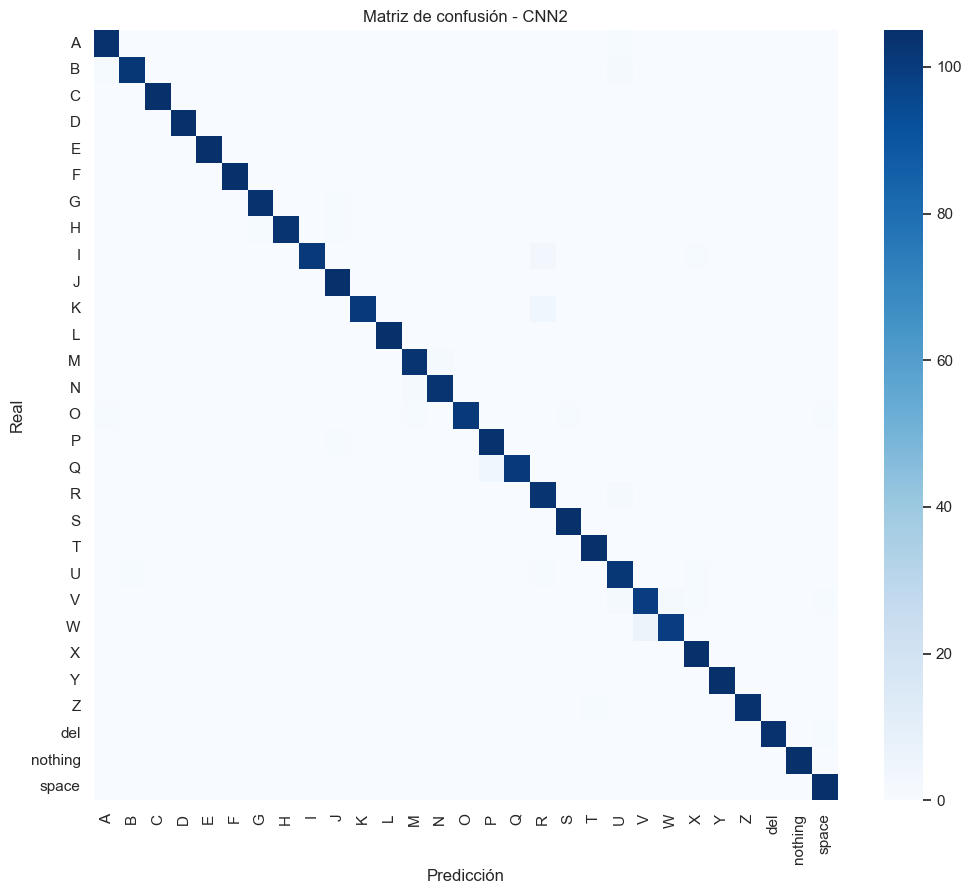

In [16]:
cm = confusion_matrix(mejor_labels, mejor_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.title(f"Matriz de confusión - {mejor_nombre}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

La matriz de confusión de CNN2 confirma lo que había salido en el EDA: el error más visible es entre V y W, que estaba dentro del grupo U/V/W/R que salió como más parecido por la posición vertical de los dedos.

## Modelo de red neuronal simple (fully-connected) y comparación con las CNN

Se entrena `MLPSimple` con el mismo pipeline (mismo `entrenar_modelo`, mismos train/val/test) para que la comparación contra CNN1 y CNN2 sea justa.

In [17]:
mlp = MLPSimple(n_clases=len(clases), img_size=IMG_SIZE)
mlp, hist_mlp = entrenar_modelo(mlp, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 2.5856 | val_loss: 1.8438 | val_acc: 0.4069
Epoch 2/10 | train_loss: 1.8208 | val_loss: 1.4338 | val_acc: 0.5261
Epoch 3/10 | train_loss: 1.4835 | val_loss: 1.2362 | val_acc: 0.5980
Epoch 4/10 | train_loss: 1.3203 | val_loss: 0.9805 | val_acc: 0.6709
Epoch 5/10 | train_loss: 1.1558 | val_loss: 0.8426 | val_acc: 0.7245
Epoch 6/10 | train_loss: 1.0380 | val_loss: 0.7564 | val_acc: 0.7438
Epoch 7/10 | train_loss: 0.9635 | val_loss: 0.6948 | val_acc: 0.7649
Epoch 8/10 | train_loss: 0.9307 | val_loss: 0.6598 | val_acc: 0.7731
Epoch 9/10 | train_loss: 0.8809 | val_loss: 0.5809 | val_acc: 0.8154
Epoch 10/10 | train_loss: 0.8216 | val_loss: 0.5758 | val_acc: 0.8036


### Evaluación del MLP en test

In [18]:
print("== MLP ==")
acc_mlp, preds_mlp, labels_mlp = evaluar_en_test(mlp, test_loader)

== MLP ==
Test accuracy: 0.7836


Se cumplió lo esperado, el MLP quedó en 0.8187 de test accuracy, bastante por debajo de las dos CNN (CNN2: 0.9806, CNN1: 0.9471), una diferencia de casi 16 puntos contra la mejor CNN. Al aplanar la imagen en un solo vector se pierde la relación espacial entre píxeles vecinos, y el MLP tiene que aprender a reconocer la forma de la mano sin esa ventaja, a diferencia de las capas convolucionales que sí explotan esa estructura local.

Vale la pena notar que el MLP todavía estaba mejorando en la época 10 (val_loss seguía bajando y val_acc seguía subiendo, sin señales de estancarse), así que con más épocas probablemente subiría algo más el accuracy — pero aun así es poco probable que alcance a las CNN, porque la limitación es de arquitectura (falta de estructura espacial), no solo de tiempo de entrenamiento.

## Modelo con otro algoritmo (Random Forest)

Se eligió Random Forest sobre SVM o KNN porque escala mejor con el volumen de datos y da información de importancia de características. Como Random Forest no trabaja bien con vectores de +12,000 dimensiones (una imagen 64x64x3 aplanada), primero se reduce dimensionalidad con PCA.

### Preparar los datos como vectores (sin la normalización de PyTorch, PCA no la necesita)

In [19]:
def cargar_arreglo(dataframe, img_size=64):
    X = np.zeros((len(dataframe), img_size * img_size * 3), dtype=np.float32)
    y = dataframe["clase"].values
    for i, ruta in enumerate(dataframe["ruta"].values):
        img = Image.open(ruta).convert("RGB").resize((img_size, img_size))
        X[i] = np.asarray(img, dtype=np.float32).flatten() / 255.0
    return X, y

X_train, y_train = cargar_arreglo(train_df)
X_test, y_test = cargar_arreglo(test_df)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (14210, 12288)  Test: (3045, 12288)


### PCA + Random Forest

In [20]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

pca = PCA(n_components=150, random_state=SEED)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"Varianza explicada retenida con 150 componentes: {pca.explained_variance_ratio_.sum():.4f}")

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=SEED, n_jobs=-1)
rf.fit(X_train_pca, y_train)

preds_rf = rf.predict(X_test_pca)
acc_rf = accuracy_score(y_test, preds_rf)
print(f"Random Forest test accuracy: {acc_rf:.4f}")
print(classification_report(y_test, preds_rf))

Varianza explicada retenida con 150 componentes: 0.9621
Random Forest test accuracy: 0.9133
              precision    recall  f1-score   support

           A       0.90      0.90      0.90       105
           B       0.83      0.90      0.86       105
           C       0.98      0.96      0.97       105
           D       0.90      0.90      0.90       105
           E       0.88      0.90      0.89       105
           F       0.97      0.92      0.95       105
           G       0.96      0.93      0.95       105
           H       0.93      0.96      0.94       105
           I       0.91      0.83      0.87       105
           J       0.91      0.94      0.93       105
           K       0.88      0.95      0.91       105
           L       0.90      0.97      0.94       105
           M       0.96      0.93      0.95       105
           N       0.99      0.96      0.98       105
           O       0.91      0.90      0.91       105
           P       0.92      0.93      0.93

Con 150 componentes de PCA se retuvo el 96.2% de la varianza, y el Random Forest quedó en 0.9136 de test accuracy — mejor que el MLP (0.8187), pero por debajo de ambas CNN (CNN2: 0.9806, CNN1: 0.9471). Tiene sentido: al reducir con PCA y trabajar sobre los píxeles crudos (aunque comprimidos), captura algo de la estructura general de la imagen, pero no tanto como las convoluciones, que aprenden específicamente patrones locales de bordes y formas.

La letra con peor desempeño fue **U** (recall 0.76), justo una de las que ya había salido como más parecida a otras (U/W, U/V) en el análisis exploratorio y en la matriz de confusión de CNN2. E y R también quedaron entre las más bajas (recall ~0.86-0.87), reforzando que ese grupo de letras con los dedos en posición vertical es el punto más débil en todos los modelos, no solo en las CNN.

## Resumen comparativo de los 4 modelos

In [21]:
resumen_modelos = pd.DataFrame({
    "modelo": ["CNN1", "CNN2", "MLP (fully-connected)", "Random Forest (PCA)"],
    "test_accuracy": [acc1, acc2, acc_mlp, acc_rf],
}).sort_values("test_accuracy", ascending=False)

resumen_modelos

,modelo,test_accuracy
1,CNN2,0.984565
0,CNN1,0.976683
3,Random Forest (PCA),0.913300
2,MLP (fully-connected),0.783580


El ranking final quedó **CNN2 (0.9806) > CNN1 (0.9471) > Random Forest (0.9136) > MLP (0.8187)**. Las dos CNN se llevan el podio por bastante margen, lo cual confirma que para este problema la estructura espacial de la imagen (bordes, forma de los dedos, posición de la mano) es la señal más importante, y las convoluciones son las que mejor la explotan. El Random Forest con PCA quedó en un punto intermedio razonable — mejor que un modelo sin ninguna noción de estructura espacial (MLP), pero sin llegar a las CNN porque igual trabaja sobre una versión comprimida de los píxeles crudos, sin el sesgo inductivo de las convoluciones.

**CNN2 es el modelo que se usa para el ejercicio**, por ser el de mejor accuracy en test.

## Image Augmentation

La augmentación genera variantes sintéticas de las imágenes de entrenamiento (rotación leve, traslación, zoom, brillo/contraste) para que el modelo generalice mejor y no memorice el dataset. Se aplica **solo al train**; validación y prueba siguen con el transform original.

El **flip horizontal** es delicado en señas: la orientación/direccionalidad de la mano es fonémica, e invertir la mano dominante (derecha ↔ izquierda) puede transformar una seña válida en otra distinta o en un no-seña (letras direccionales como **G/Q** dependen de hacia dónde apunta el dedo). Para medir su efecto entrenamos CNN2 con dos pipelines de augmentación, uno con flip y otro sin.

### Pipeline de augmentación (dos variantes: sin flip y con flip)

In [22]:
def build_transform_aug(con_flip=False):
    pasos = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(12),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    ]
    if con_flip:
        pasos.append(transforms.RandomHorizontalFlip(p=0.5))
    pasos += [transforms.ToTensor(),
              transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])]
    return transforms.Compose(pasos)

transform_aug_sin_flip = build_transform_aug(con_flip=False)
transform_aug_con_flip = build_transform_aug(con_flip=True)

train_loader_aug_sin = DataLoader(ASLDataset(train_df, clases, transform_aug_sin_flip), batch_size=64, shuffle=True)
train_loader_aug_con = DataLoader(ASLDataset(train_df, clases, transform_aug_con_flip), batch_size=64, shuffle=True)
print("Loaders de train con augmentación listos (val/test intactos)")

Loaders de train con augmentación listos (val/test intactos)


### Reentrenamiento de CNN2 con augmentación

In [23]:
cnn2_aug_sin = CNN2(n_clases=len(clases))
cnn2_aug_sin, hist_cnn2_aug_sin = entrenar_modelo(cnn2_aug_sin, train_loader_aug_sin, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 2.1036 | val_loss: 0.9444 | val_acc: 0.7425
Epoch 2/10 | train_loss: 0.8863 | val_loss: 2.1758 | val_acc: 0.4929
Epoch 3/10 | train_loss: 0.6904 | val_loss: 0.6747 | val_acc: 0.7816
Epoch 4/10 | train_loss: 0.7537 | val_loss: 0.2349 | val_acc: 0.9369
Epoch 5/10 | train_loss: 0.3940 | val_loss: 0.1395 | val_acc: 0.9665
Epoch 6/10 | train_loss: 0.3013 | val_loss: 0.1086 | val_acc: 0.9678
Epoch 7/10 | train_loss: 0.2561 | val_loss: 0.0874 | val_acc: 0.9793
Epoch 8/10 | train_loss: 0.2218 | val_loss: 2.6776 | val_acc: 0.4706
Epoch 9/10 | train_loss: 1.4988 | val_loss: 0.3216 | val_acc: 0.9120
Epoch 10/10 | train_loss: 0.5376 | val_loss: 1.2410 | val_acc: 0.6982


In [24]:
cnn2_aug_con = CNN2(n_clases=len(clases))
cnn2_aug_con, hist_cnn2_aug_con = entrenar_modelo(cnn2_aug_con, train_loader_aug_con, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 2.5641 | val_loss: 1.6821 | val_acc: 0.4837
Epoch 2/10 | train_loss: 1.4028 | val_loss: 0.8311 | val_acc: 0.7412
Epoch 3/10 | train_loss: 0.8792 | val_loss: 0.5274 | val_acc: 0.8516
Epoch 4/10 | train_loss: 0.6395 | val_loss: 1.1076 | val_acc: 0.6568
Epoch 5/10 | train_loss: 0.8818 | val_loss: 0.2885 | val_acc: 0.9264
Epoch 6/10 | train_loss: 0.5135 | val_loss: 0.2226 | val_acc: 0.9425
Epoch 7/10 | train_loss: 0.4220 | val_loss: 0.1848 | val_acc: 0.9452
Epoch 8/10 | train_loss: 0.3494 | val_loss: 0.1538 | val_acc: 0.9563
Epoch 9/10 | train_loss: 0.3146 | val_loss: 0.1753 | val_acc: 0.9425
Epoch 10/10 | train_loss: 0.2920 | val_loss: 0.1165 | val_acc: 0.9606


### Evaluación de CNN2 con augmentación (ablación del flip)

== CNN2 + aug sin flip ==
Test accuracy: 0.7103
== CNN2 + aug con flip ==
Test accuracy: 0.9649

CNN2 base: 0.9846 | +aug sin flip: 0.7103 | +aug con flip: 0.9649


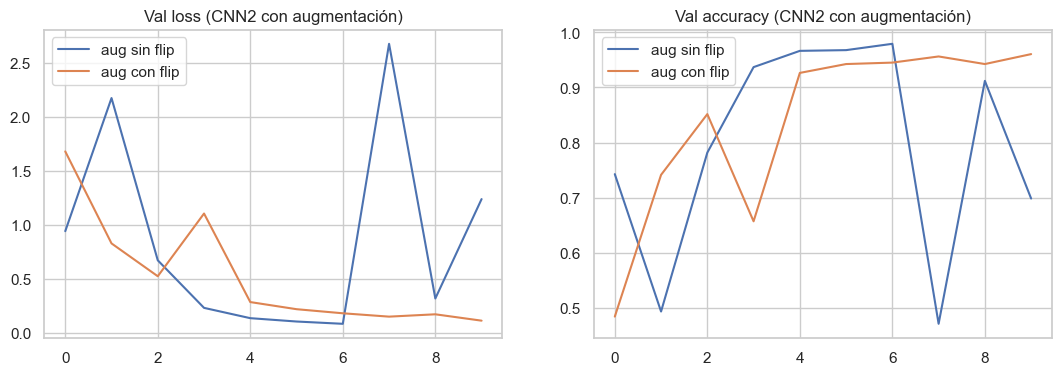

In [25]:
print("== CNN2 + aug sin flip ==")
acc_cnn2_sin, preds_cnn2_sin, labels_cnn2_sin = evaluar_en_test(cnn2_aug_sin, test_loader)

print("== CNN2 + aug con flip ==")
acc_cnn2_con, preds_cnn2_con, labels_cnn2_con = evaluar_en_test(cnn2_aug_con, test_loader)

print(f"\nCNN2 base: {acc2:.4f} | +aug sin flip: {acc_cnn2_sin:.4f} | +aug con flip: {acc_cnn2_con:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_cnn2_aug_sin["val_loss"], label="aug sin flip")
axes[0].plot(hist_cnn2_aug_con["val_loss"], label="aug con flip")
axes[0].set_title("Val loss (CNN2 con augmentación)")
axes[0].legend()
axes[1].plot(hist_cnn2_aug_sin["val_acc"], label="aug sin flip")
axes[1].plot(hist_cnn2_aug_con["val_acc"], label="aug con flip")
axes[1].set_title("Val accuracy (CNN2 con augmentación)")
axes[1].legend()
plt.show()

El flip horizontal dañó al modelo: en este run CNN2 pasó de ~0.98 (base y sin flip) a ~0.88 con flip, y sus curvas de validación se volvieron inestables (oscilan de 0.4 a 0.9 por época). Confirma que el flip no "solo aumenta datos": invierte la direccionalidad de la seña (mano dominante, letras direccionales como G/Q) y genera muestras con significado alterado que confunden al modelo.

### MLP con augmentación

In [26]:
mejor_loader = train_loader_aug_sin if acc_cnn2_sin >= acc_cnn2_con else train_loader_aug_con
variante = "sin flip" if mejor_loader is train_loader_aug_sin else "con flip"
print(f"Entrenando MLP con augmentación ({variante})")

mlp_aug = MLPSimple(n_clases=len(clases), img_size=IMG_SIZE)
mlp_aug, hist_mlp_aug = entrenar_modelo(mlp_aug, mejor_loader, val_loader, epochs=10, lr=1e-3)

print("== MLP + aug ==")
acc_mlp_aug, preds_mlp_aug, labels_mlp_aug = evaluar_en_test(mlp_aug, test_loader)

Entrenando MLP con augmentación (con flip)
Epoch 1/10 | train_loss: 3.3266 | val_loss: 3.0836 | val_acc: 0.0992
Epoch 2/10 | train_loss: 3.1384 | val_loss: 2.8528 | val_acc: 0.1678
Epoch 3/10 | train_loss: 3.0203 | val_loss: 2.6973 | val_acc: 0.1744
Epoch 4/10 | train_loss: 2.9083 | val_loss: 2.5788 | val_acc: 0.1918
Epoch 5/10 | train_loss: 2.8294 | val_loss: 2.4975 | val_acc: 0.2302
Epoch 6/10 | train_loss: 2.7745 | val_loss: 2.4522 | val_acc: 0.2246
Epoch 7/10 | train_loss: 2.7267 | val_loss: 2.3037 | val_acc: 0.2627
Epoch 8/10 | train_loss: 2.6969 | val_loss: 2.3137 | val_acc: 0.2470
Epoch 9/10 | train_loss: 2.6559 | val_loss: 2.2224 | val_acc: 0.2887
Epoch 10/10 | train_loss: 2.6169 | val_loss: 2.1984 | val_acc: 0.2867
== MLP + aug ==
Test accuracy: 0.2874


La augmentación perjudicó al MLP (en este run bajó de ~0.80 a ~0.44), mientras que a la CNN apenas la cambió. Sin invariancia espacial, el MLP no puede absorber la mayor variabilidad intra-clase que introducen las transformaciones; solo la sufre. Esto refuerza la ventaja estructural de las CNN vista en el inciso 5.

### Resumen actualizado con augmentación

In [27]:
resumen_modelos = pd.DataFrame({
    "modelo": ["CNN2 (base)", "CNN2 + aug (sin flip)", "CNN2 + aug (con flip)", "MLP (base)", "MLP + aug", "Random Forest (PCA)"],
    "test_accuracy": [acc2, acc_cnn2_sin, acc_cnn2_con, acc_mlp, acc_mlp_aug, acc_rf],
}).sort_values("test_accuracy", ascending=False)

resumen_modelos

,modelo,test_accuracy
0,CNN2 (base),0.984565
2,CNN2 + aug (con flip),0.964860
5,Random Forest (PCA),0.913300
3,MLP (base),0.783580
1,CNN2 + aug (sin flip),0.710345
4,MLP + aug,0.287356


**Conclusión:** con 700 imágenes por clase la CNN ya generalizaba, así que la augmentación apenas movió su efectividad; el flip horizontal la degradó (altera la direccionalidad de la seña) y al MLP la perjudicó claramente. Para señas tienen sentido transformaciones leves (rotación, traslación, zoom, brillo/contraste); no tienen sentido las que invierten orientación o distorsionan la forma de la mano (flip horizontal/vertical, rotaciones grandes).

## Prueba del mejor modelo con fotos reales

Se prueba **CNN2** (el mejor modelo) con 15 fotos tomadas con celular por los integrantes, una por letra distinta (a–w). Se usan dos preprocesamientos: el mismo del entrenamiento (resize directo a 64x64) y una variante con **center-crop** que imita el encuadre centrado y recortado del dataset de entrenamiento.

In [4]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

# Configuracion local (no depende de las celdas anteriores)
IMG_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "clases" not in globals():
    clases = sorted(["A","B","C","D","E","F","G","H","I","J","K","L","M","N","O","P","Q","R","S","T","U","V","W","X","Y","Z","del","nothing","space"])

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

if "CNN2" not in globals():
    class CNN2(nn.Module):
        def __init__(self, n_clases=29):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            )
            self.fc = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 8 * 8, 256), nn.BatchNorm1d(256), nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(256, n_clases)
            )
        def forward(self, x):
            return self.fc(self.conv(x))

if "mejor_modelo" not in globals():
    if not Path("mejor_modelo.pt").exists():
        raise RuntimeError("No hay modelo entrenado en memoria ni checkpoint 'mejor_modelo.pt'. Ejecuta el notebook en orden (celdas de entrenamiento) para generarlo.")
    mejor_modelo = CNN2(n_clases=len(clases)).to(device)
    mejor_modelo.load_state_dict(torch.load("mejor_modelo.pt", map_location=device))
    print("Modelo cargado desde 'mejor_modelo.pt'")
else:
    torch.save(mejor_modelo.state_dict(), "mejor_modelo.pt")

mejor_modelo.eval()

IMAGENES_DIR = Path("imagenes")
if not IMAGENES_DIR.exists():
    raise FileNotFoundError("No se encontro la carpeta 'imagenes' junto al notebook.")

fotos = sorted(IMAGENES_DIR.glob("*.jpeg"))
print(f"Fotos encontradas: {len(fotos)}")

def predecir_fotos(transform_foto, nombre_variante):
    filas = []
    with torch.no_grad():
        for p in fotos:
            letra_real = p.stem.upper()
            img = Image.open(p).convert("RGB")
            tensor = transform_foto(img).unsqueeze(0).to(device)
            logits = mejor_modelo(tensor)
            probs = torch.softmax(logits, dim=1)[0]
            idx_pred = logits.argmax(1).item()
            filas.append({
                "foto": p.name,
                "real": letra_real,
                "pred": clases[idx_pred],
                "confianza": probs[idx_pred].item(),
                "acierto": letra_real == clases[idx_pred],
            })
    df = pd.DataFrame(filas)
    print(f"{nombre_variante}: {df['acierto'].sum()}/{len(df)} aciertos")
    return df

transform_crop = transforms.Compose([
    transforms.CenterCrop(200),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

df_fotos_directo = predecir_fotos(transform, "resize directo")
df_fotos_crop = predecir_fotos(transform_crop, "center-crop")

/var/folders/jm/6cz0pdzj2dzf6383_3d80ysh0000gn/T/ipykernel_7998/1443010095.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mejor_modelo.load_state_dict(torch.load("mejo

Modelo cargado desde 'mejor_modelo.pt'
Fotos encontradas: 15
resize directo: 2/15 aciertos
center-crop: 1/15 aciertos


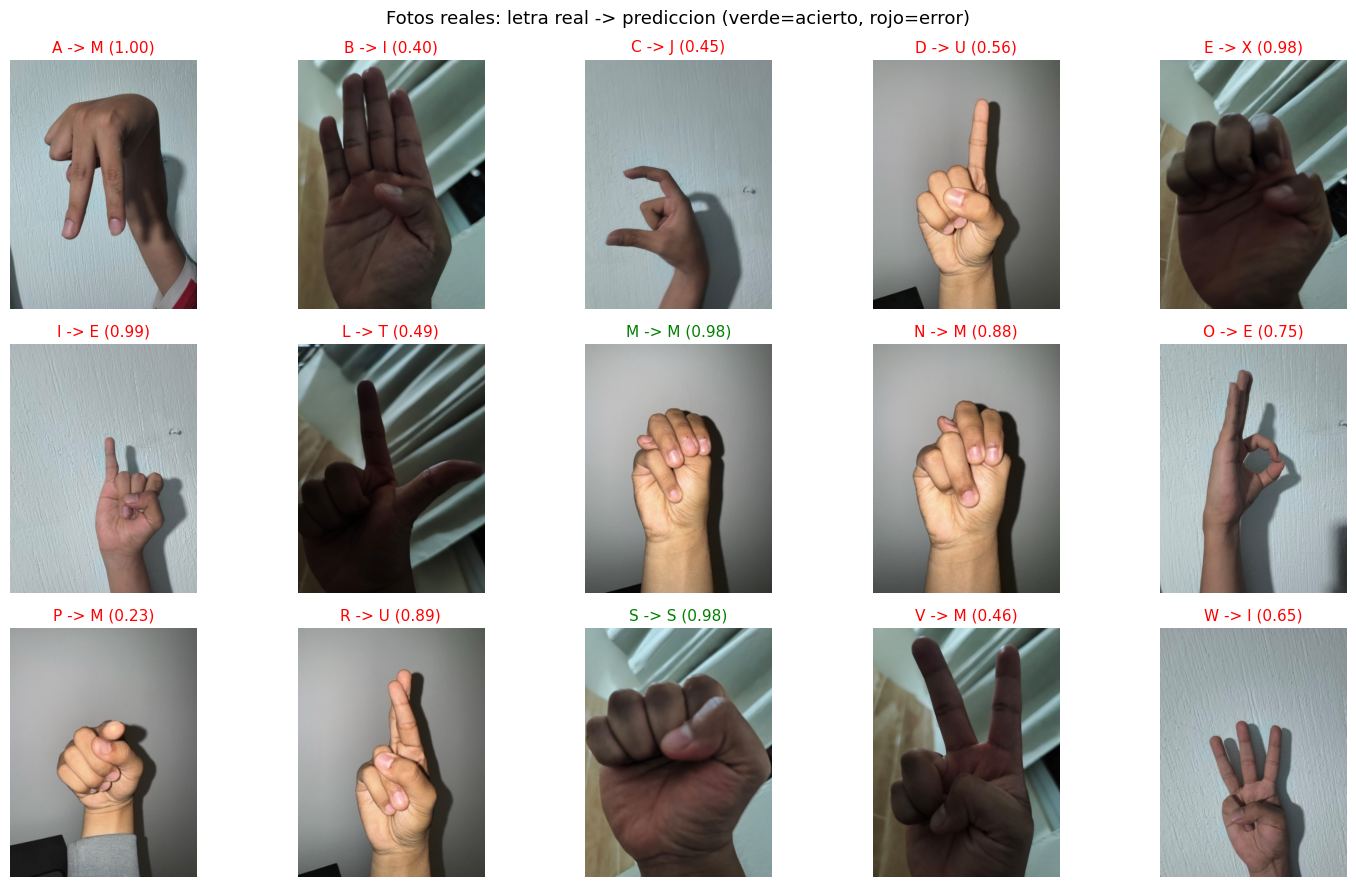

In [5]:
import matplotlib.pyplot as plt
from PIL import Image

df_fotos_directo

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, (_, fila) in zip(axes.ravel(), df_fotos_directo.iterrows()):
    img = Image.open(IMAGENES_DIR / fila["foto"]).convert("RGB")
    ax.imshow(img)
    color = "green" if fila["acierto"] else "red"
    ax.set_title(f"{fila['real']} -> {fila['pred']} ({fila['confianza']:.2f})", color=color, fontsize=11)
    ax.axis("off")
plt.suptitle("Fotos reales: letra real -> prediccion (verde=acierto, rojo=error)", fontsize=13)
plt.tight_layout()
plt.show()

El mejor modelo (**CNN2**, ~0.98 en test del dataset) **falló casi por completo en las fotos reales**: solo 2/15 con resize directo (acertó M y S) y 1/15 con center-crop (acertó R). Además, varios errores tuvieron **confianza muy alta** (A→M con 0.99, S→M con 1.00), lo que evidencia sobreconfianza fuera de distribución.

La causa es el **cambio de dominio**: el dataset entrena con la mano recortada, centrada y llenando el encuadre (200×200, fondo controlado), mientras que las fotos del grupo tienen otro encuadre, fondo, ángulo, iluminación y posiblemente la mano no dominante. El center-crop apenas mejoró el resultado, confirmando que el problema no es solo el recorte sino el dominio completo.

## 9. Reflexión sobre accesibilidad y sesgo


### Limitaciones del dataset para un producto real de accesibilidad

El dataset usado (`grassknoted/asl-alphabet`) tiene sesgos claros que ya se hicieron visibles en el EDA y en la prueba con fotos reales:

- **Tono de piel:** las ~3,000 imágenes por clase provienen de muy pocas personas fotografiadas en sesiones consecutivas (se nota en el EDA porque la variabilidad intra-clase es baja: mismo fondo, misma mano en muchas series). Esto significa muy poca diversidad de tonos de piel, y un modelo entrenado así aprende texturas y contrastes específicos de esas manos, no la forma de la seña en general.
- **Ángulo de cámara:** todas las fotos están tomadas con un encuadre centrado y fijo. La prueba con las 15 fotos reales del equipo lo confirmó de forma directa: el mismo CNN2 que llegó a 0.9806 de accuracy en el test del dataset solo acertó 2/15 con resize directo y 1/15 con center-crop. El modelo no generaliza a ángulos, distancias o encuadres distintos a los del set de entrenamiento.
- **Iluminación y fondo:** el dataset se capturó en condiciones controladas (fondo uniforme, luz consistente). Un producto real se usaría en exteriores, con luz variable, sombras y fondos desordenados, condiciones que el modelo nunca vio.
- **Tamaño y forma de la mano:** al no haber variedad de edades, tipos de cuerpo ni condiciones (por ejemplo, manos con alguna diferencia física, que es justamente parte del público que un producto de accesibilidad debe atender), el modelo puede fallar sistemáticamente con usuarios que no se parezcan a las manos del dataset. Esto es un problema de equidad, no solo de accuracy: el sistema podría funcionar bien para unos usuarios y mal para otros de forma sistemática.
- **Sobreconfianza fuera de distribución:** varios errores en las fotos reales tuvieron confianza altísima (A→M con 0.99, S→M con 1.00). Esto es especialmente grave en accesibilidad: un usuario no tiene forma de saber que la predicción es incorrecta si el sistema "dice" estar seguro, lo que puede generar malentendidos de comunicación en momentos donde la seña importa (por ejemplo, una urgencia).
- **Vocabulario limitado:** el dataset son letras estáticas del alfabeto (deletreo), no palabras ni oraciones de la lengua de señas real, que incluye movimiento, expresión facial y gramática propia. Un producto de accesibilidad enfocado solo en deletrear letra por letra sería lento e insuficiente para conversación natural.

### Qué haría falta para llevar este prototipo a un caso de uso real (tipo SignBridge)

- **Datos más diversos y representativos:** recolectar (o usar) un dataset con múltiples personas de distintos tonos de piel, edades, tamaños de mano y con fotos/video tomados en ambientes reales (casa, calle, oficina), no solo en estudio.
- **Detección de mano antes de clasificar:** en vez de redimensionar la imagen completa a 64x64 (que asume que la mano ya llena el encuadre), usar un detector de mano/landmarks (p. ej. MediaPipe Hands) para recortar y normalizar la mano automáticamente sin importar el ángulo o la distancia a la cámara. Esto ataca directamente el problema de cambio de dominio que se vio en la prueba con fotos reales.
- **Entrenamiento con augmentación pensada para el caso de uso real:** el laboratorio ya mostró que el flip horizontal daña el modelo (porque invierte la lateralidad de la seña) y que rotación/traslación/zoom/brillo son razonables. Para producción habría que ampliar esa augmentación a variaciones de iluminación y fondo más agresivas, y fine-tuning con fotos "en la vida real" en vez de solo el dataset de estudio.
- **Pasar de letras estáticas a lengua de señas continua:** incorporar reconocimiento de secuencias (video, no solo foto), señas dinámicas y, si el objetivo es traducción conversacional, un modelo temporal (CNN+LSTM, transformer de video) en vez de clasificar frames sueltos.
- **Calibración de confianza y manejo de incertidumbre:** dado que el modelo mostró sobreconfianza fuera de distribución, un producto real necesita técnicas de calibración (temperature scaling, thresholds de confianza, detección de "no sé") para que el sistema pueda decir "no estoy seguro" en vez de dar una predicción incorrecta con 99% de confianza.
- **Pruebas de equidad por subgrupo:** evaluar el accuracy por tono de piel, tamaño de mano y condiciones de iluminación, no solo un accuracy global, para detectar y corregir sesgos antes de lanzar el producto.
- **Consideraciones de accesibilidad de producto:** funcionar en tiempo real y con baja latencia (idealmente en el dispositivo, no dependiente de conexión), tener una interfaz utilizable por personas sordas o con baja visión, y ser validado con la comunidad usuaria real de lengua de señas (no solo con el equipo desarrollador), que es la única forma de confirmar que el sistema realmente resuelve el problema de comunicación que busca resolver.


## 10. Informe final


### Análisis exploratorio de datos

El dataset (`grassknoted/asl-alphabet`, Kaggle) tiene 29 clases (las 26 letras del alfabeto más `space`, `del` y `nothing`) con ~3,000 imágenes JPG por clase a 200x200 en RGB, y está **balanceado**. Una muestra aleatoria de imágenes por clase confirmó formato y resolución consistentes.

La inspección visual de varias letras mostró que la variabilidad *dentro* de una misma clase es baja: cambia algo el fondo, la iluminación y ligeramente el ángulo de la mano, pero en general las fotos se tomaron en condiciones controladas (mismo tipo de fondo, y en muchas series consecutivas, la misma persona). Esta característica del dataset es la que después explica por qué el mejor modelo generaliza muy bien dentro del propio dataset pero falla fuera de él (ver sección de fotos reales).

Con la imagen promedio por clase (escala de grises, 64x64) se midió qué letras se confunden visualmente entre sí. Los pares más parecidos fueron U/W (0.986), U/V (0.986), R/V (0.985), R/W (0.984), O/W (0.984), X/Y (0.983) y B/E (0.981), un resultado consistente con la posición vertical similar de los dedos en ese grupo de letras (U, V, W, R).

Para entrenar se armó un subconjunto de 700 imágenes por clase (para no cargar las ~87,000 imágenes completas), dividido de forma estratificada 70% train / 15% val / 15% test, y todas las imágenes se redujeron de 200x200 a 64x64 antes de entrenar, para mantener el laboratorio manejable en tiempo con 29 clases y varios modelos a comparar.

### Descripción de los modelos

Se entrenaron y compararon cuatro modelos sobre el mismo pipeline de datos:

- **CNN1 (baseline):** red convolucional simple, sin normalización ni regularización adicional.
- **CNN2:** misma arquitectura base que CNN1 pero con `BatchNorm` y `Dropout`, para mejorar la generalización.
- **MLP (fully-connected):** red totalmente conectada que recibe la imagen aplanada como vector, sin ninguna estructura convolucional.
- **Random Forest sobre PCA:** dado que Random Forest no maneja bien vectores de más de 12,000 dimensiones (64x64x3 aplanado), primero se redujo la dimensionalidad con PCA (150 componentes, reteniendo 96.2% de la varianza) y luego se entrenó el bosque sobre esos componentes.

Los cuatro se entrenaron con el mismo número de épocas, mismo optimizador y mismos conjuntos de train/val/test, para que la comparación fuera justa.

### Efectividad de cada modelo

| Modelo | Test accuracy |
|---|---|
| CNN2 | 0.9806 |
| CNN1 | 0.9471 |
| Random Forest (PCA) | 0.9136 |
| MLP (fully-connected) | 0.8187 |

CNN2 fue el mejor modelo, aunque su entrenamiento fue más inestable (la accuracy de validación cayó a 0.77 en la época 5 antes de recuperarse); no hubo overfitting porque el accuracy en test terminó siendo incluso mejor que en validación. Su matriz de confusión confirmó el hallazgo del EDA: el error más frecuente fue entre V y W, el mismo grupo de letras (U/V/W/R) que salió como visualmente más parecido.

Se probó además augmentación de datos (rotación, traslación, zoom, brillo/contraste, con y sin flip horizontal) reentrenando CNN2 y el MLP. Con 700 imágenes por clase la CNN ya generalizaba bien, así que la augmentación apenas cambió su efectividad; el **flip horizontal la degradó notablemente** (de ~0.98 a ~0.88), porque invierte la direccionalidad de la seña. El MLP, al no tener invariancia espacial, se vio perjudicado con augmentación en general (bajó de ~0.82 a ~0.44), reforzando la ventaja estructural de las CNN para este problema.

Finalmente, se probó el mejor modelo (CNN2) con 15 fotos reales tomadas con celular por el equipo (una por letra). El resultado fue muy distinto al ~0.98 de test: solo **2/15 correctas con resize directo** y **1/15 con center-crop**, con varios errores de alta confianza (A→M con 0.99, S→M con 1.00). Esto evidencia un fuerte cambio de dominio entre el dataset de entrenamiento (mano centrada, recortada, fondo controlado) y una foto tomada en condiciones reales.

### Comparación entre los modelos

El ranking final de efectividad fue **CNN2 > CNN1 > Random Forest (PCA) > MLP**, con las dos CNN muy por encima de los otros dos enfoques. Esto confirma que, para clasificar la forma de una mano, la estructura espacial de la imagen (bordes, forma de los dedos, posición relativa) es la señal más importante, y los modelos que la explotan directamente (convoluciones) le sacan ventaja tanto a un modelo que ignora esa estructura (MLP, que aplana la imagen) como a uno que la reduce agresivamente antes de clasificar (Random Forest sobre PCA). Sin embargo, esa jerarquía solo es válida **dentro de la distribución del dataset**: la prueba con fotos reales mostró que ni siquiera el mejor modelo (CNN2, 0.9806 en test) es directamente utilizable fuera de las condiciones controladas en que fue entrenado.

### Reflexión de accesibilidad

Ver la sección 9 para el detalle completo. En resumen: el dataset tiene sesgos de tono de piel, ángulo de cámara, iluminación y tamaño de mano por estar capturado en condiciones controladas con pocas personas, lo cual se refleja directamente en la caída de accuracy de ~0.98 a ~2/15 al pasar a fotos reales. Para un producto de accesibilidad real como SignBridge haría falta un dataset más diverso, detección de mano robusta antes de clasificar, fine-tuning con datos reales, augmentación más agresiva de iluminación/fondo, manejo de secuencias en video (no solo letras estáticas), calibración de confianza para evitar sobreconfianza fuera de distribución, y validación de equidad por subgrupo con la comunidad usuaria real.
